In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import RobustScaler

sys.path.append(str(Path.cwd().parent))

from src.config import MODELS_DIR, RANDOM_STATE  # noqa: E402
from src.data_loader import load_data  # noqa: E402
from src.evaluate import (  # noqa: E402
    plot_confusion_matrices, plot_pr_curves)
from src.preprocessing import (  # noqa: E402
    build_preprocessor, remove_duplicates)
from src.split import (  # noqa: E402
    stratified_split, summarize_split, time_based_split)
from src.train_baseline import (  # noqa: E402
    fit_and_save_best, run_experiments)

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

1. Remove duplicates

Exact duplicates are the same transaction recorded twice. If one copy lands in train and one in test, evaluation is over-optimistic. Dropping rows learns nothing from the data, so this step is safe before the split.

In [2]:
df = load_data(verbose=False)
df, n_removed = remove_duplicates(df)
print(df.shape, df["Class"].value_counts().to_dict())

Removed 1,081 duplicate rows (0.380%); 283,726 rows remain.
(283726, 31) {0: 283253, 1: 473}


2. Stratified train/test split

We split first, before any scaling or resampling. Stratification keeps the fraud ratio equal in both sets, which matters with only a few hundred positives.

In [3]:
X_train, X_test, y_train, y_test = stratified_split(df)
split_summary = summarize_split(y_train, y_test, "Stratified 80/20")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


Stratified 80/20
       n_rows  n_fraud  n_legit  fraud_pct
train  226980      378   226602     0.1665
test    56746       95    56651     0.1674
X_train: (226980, 30) | X_test: (56746, 30)


3. Time-based split (robustness check only)

Train on the earliest 80% of transactions, test on the latest 20%. This mimics deployment. Notice the fraud ratio is no longer perfectly matched. We use this later as a sanity check, not as the main split.

In [4]:
Xt_train, Xt_test, yt_train, yt_test = time_based_split(df)
summarize_split(yt_train, yt_test, "Time-based 80/20")
print(
    f"Train Time max = {Xt_train['Time'].max():,.0f}s | "
    f"Test Time min = {Xt_test['Time'].min():,.0f}s"
)


Time-based 80/20
       n_rows  n_fraud  n_legit  fraud_pct
train  226980      399   226581     0.1758
test    56746       74    56672     0.1304
Train Time max = 145,233s | Test Time min = 145,234s


4. Raw Amount vs. log_amount

We compare on the training set only. RobustScaler is linear, so it rescales but cannot change skewness. Only log1p makes the distribution roughly symmetric. We still scale afterwards because median/IQR are robust to Amount's extreme outliers, unlike mean/std in StandardScaler.

In [5]:
amount = X_train["Amount"]
log_amount = np.log1p(amount)


def robust(series: pd.Series) -> pd.Series:
    """RobustScale a series (fit on training data only)."""
    values = RobustScaler().fit_transform(series.to_frame()).ravel()
    return pd.Series(values, index=series.index)


comparison = pd.DataFrame({
    "Amount": amount,
    "RobustScaler(Amount)": robust(amount),
    "log_amount": log_amount,
    "RobustScaler(log_amount)": robust(log_amount),
}).agg(["median", "std", "skew", "max"]).T
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(amount.clip(upper=500), bins=60, ax=axes[0])
axes[0].set_title("Amount (clipped at 500 for display)")
sns.histplot(log_amount, bins=60, ax=axes[1])
axes[1].set_title("log_amount = log1p(Amount)")
plt.tight_layout()
plt.show()

,median,std,skew,max
Amount,22.080,245.767,14.393,19656.530
RobustScaler(Amount),0.000,3.406,14.393,272.096
log_amount,3.139,1.656,0.159,9.886
RobustScaler(log_amount),0.000,0.671,0.159,2.735


<Figure size 1200x400 with 2 Axes>

5. Fit on train, transform test

The scaler learns its median and IQR from training data only. As a sanity check, the train medians of the scaled columns are exactly 0, while the test medians are only close to 0. That small gap shows the test set was not used to fit the scaler. This is a shape and sanity check only, and nothing is evaluated on the test set.

In [6]:
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print("Transformed shapes:", X_train_t.shape, X_test_t.shape)

scaler = preprocessor.named_steps["columns"].named_transformers_["robust"]
print("Learned centers:", dict(zip(["log_amount", "Time"],
                                   scaler.center_.round(3))))

cols = ["log_amount", "Time"]
display(pd.DataFrame({
    "train median": X_train_t[cols].median(),
    "test median": X_test_t[cols].median(),
}).round(4))

Transformed shapes: (226980, 31) (56746, 31)
Learned centers: {'log_amount': 3.139, 'Time': 84816.0}


,train median,test median
log_amount,0.0,-0.0088
Time,0.0,-0.0041


6. Compare models × imbalance strategies

Five strategies × two models = 10 experiments, each with stratified 5-fold CV on the training set. Resampling is inside the pipeline, so it only touches the training portion of each fold. Runtime: roughly 10-25 minutes, mostly the Random Forest with SMOTE. For a quick first pass, use model_names=("logreg",).

In [7]:
results, oof = run_experiments(X_train, y_train)

logreg + none                PR-AUC=0.751 recall=0.611 (5s)
logreg + class_weight        PR-AUC=0.740 recall=0.915 (11s)
logreg + undersample         PR-AUC=0.579 recall=0.910 (2s)


c:\Users\gopu8\OneDrive\Desktop\ML_PROJ\credit-card-fraud-detection\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\gopu8\OneDrive\Desktop\ML_PROJ\credit-card-fraud-detection\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\gopu8\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\gopu8\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args,

logreg + smote               PR-AUC=0.742 recall=0.907 (21s)
logreg + smote_under         PR-AUC=0.743 recall=0.892 (5s)
rf + none                    PR-AUC=0.839 recall=0.775 (131s)
rf + class_weight            PR-AUC=0.827 recall=0.794 (95s)
rf + undersample             PR-AUC=0.753 recall=0.905 (4s)
rf + smote                   PR-AUC=0.818 recall=0.825 (234s)
rf + smote_under             PR-AUC=0.827 recall=0.844 (28s)


7. Results

Columns are fold-means. pr_auc_std shows fold-to-fold variability. With only about 75 frauds per validation fold, expect noticeable variance, so treat small differences as noise. tn/fp/fn/tp are pooled out-of-fold counts at threshold 0.5. Accuracy is deliberately absent.

In [8]:
table = results.sort_values("pr_auc", ascending=False)
display(table.round(3))

# Sanity checks: counts must add up to the training set
assert (results[["tn", "fp", "fn", "tp"]].sum(axis=1)
        == len(y_train)).all()
assert (results["tp"] + results["fn"] == y_train.sum()).all()

,precision,recall,f1,pr_auc,roc_auc,pr_auc_std,tn,fp,fn,tp
model + strategy,,,,,,,,,,
rf + none,0.937,0.775,0.846,0.839,0.976,0.036,226582,20,85,293
rf + class_weight,0.882,0.794,0.833,0.827,0.965,0.038,226561,41,78,300
rf + smote_under,0.666,0.844,0.744,0.827,0.984,0.035,226442,160,59,319
rf + smote,0.674,0.825,0.740,0.818,0.982,0.036,226447,155,66,312
rf + undersample,0.068,0.905,0.126,0.753,0.979,0.060,221827,4775,36,342
logreg + none,0.857,0.611,0.711,0.751,0.976,0.039,226563,39,147,231
logreg + smote_under,0.106,0.892,0.189,0.743,0.981,0.030,223702,2900,41,337
logreg + smote,0.056,0.907,0.105,0.742,0.981,0.029,220741,5861,35,343
logreg + class_weight,0.059,0.915,0.110,0.740,0.982,0.030,221009,5593,32,346


8. Precision-Recall curves

We plot the top 4 combinations by PR-AUC using out-of-fold predictions. The dashed line is a no-skill classifier, whose precision equals the fraud prevalence. A curve that stays high and to the right is better.

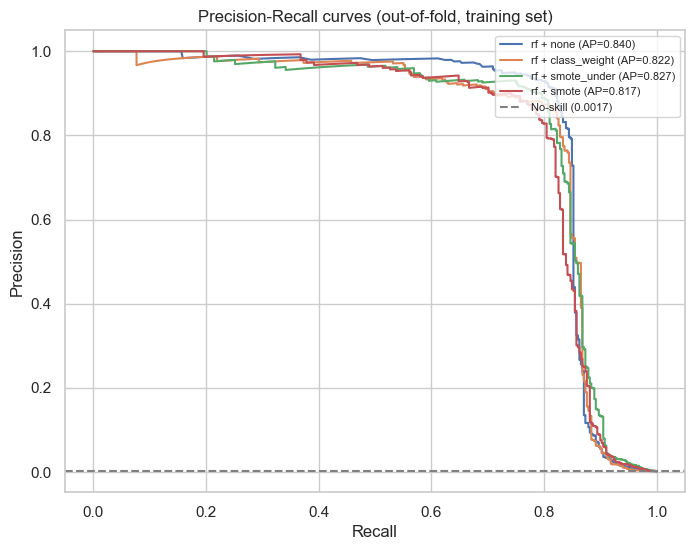

No-skill PR-AUC (prevalence): 0.0017
'Always legit' accuracy:      99.8335%


In [9]:
top_labels = list(table.head(4).index)
plot_pr_curves(y_train, {k: oof[k] for k in top_labels})
plt.show()

print(f"No-skill PR-AUC (prevalence): {y_train.mean():.4f}")
print(f"'Always legit' accuracy:      {1 - y_train.mean():.4%}")

9. Confusion matrices (threshold = 0.5)

This is where the precision/recall trade-off becomes concrete: how many frauds did we catch (TP), miss (FN), and how many legit customers did we flag (FP)? The colors are dominated by the huge TN cell, so read the numbers.

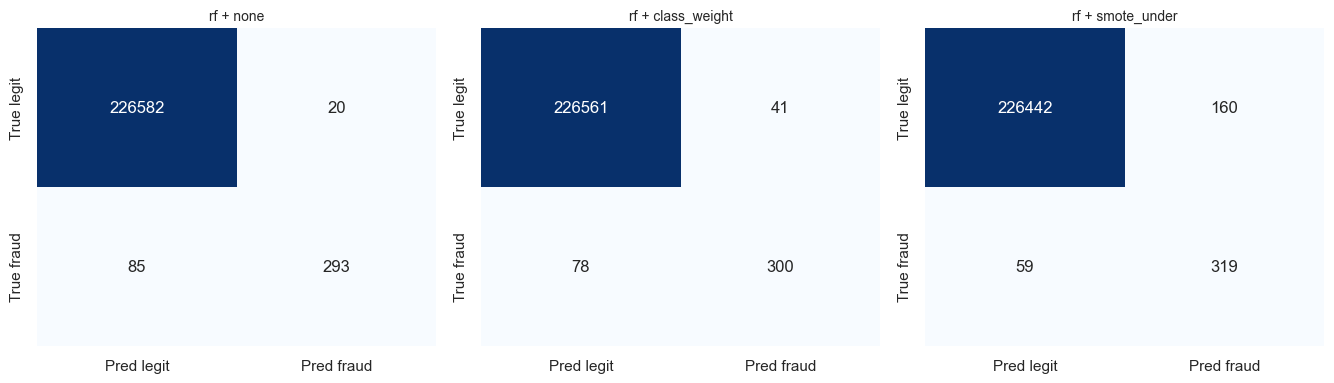

In [10]:
plot_confusion_matrices(y_train, {k: oof[k] for k in top_labels[:3]})
plt.show()

10. Save artifacts

We pick the best combination by PR-AUC (threshold-independent), refit it on all training data, and save the full pipeline and the fitted preprocessor. The reload check proves the saved pipeline accepts raw input, which is what the API will send.

In [11]:
best_label = results["pr_auc"].idxmax()
print("Best baseline by PR-AUC:", best_label)
best_pipeline = fit_and_save_best(best_label, X_train, y_train)

loaded = joblib.load(MODELS_DIR / "best_baseline.joblib")
print(loaded.predict_proba(X_train.head(3))[:, 1])
print(sorted(p.name for p in MODELS_DIR.glob("*.joblib")))

Best baseline by PR-AUC: rf + none
[9.23071242e-05 8.98193840e-05 1.31264903e-04]
['best_baseline.joblib', 'preprocessor.joblib']


## Key Findings

1. **1,081 duplicates** were removed; after cleaning there are **473 frauds in 283,726 rows (0.167%)**.

2. `log_amount` reduced the skew of `Amount`, while `RobustScaler` alone did not change the underlying skewness.

3. The **best baseline by PR-AUC** was **Random Forest + none**, with **PR-AUC = 0.839 ± 0.036**.

4. Resampling and class weights generally increased recall but reduced precision. `rf + none` achieved **93.7% precision and 77.5% recall**, while `rf + smote_under` achieved **66.6% precision and 84.4% recall**.

5. ROC-AUC was high across almost all models (**0.965–0.984**), while PR-AUC provided a clearer comparison for the highly imbalanced dataset.

6. Fold-to-fold PR-AUC standard deviation ranged from **0.029 to 0.130**, so small PR-AUC differences should be interpreted cautiously.